In [1]:
#description: this program uses an artificial recuurent neural network called long short term memory (lstm) to predict
# the closing stock price of a corportation (apple inc) using the past 60 days stock price

In [2]:
import math
import yfinance as yf
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import Dense, LSTM
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')


In [3]:
#%pip install tensorflow

In [4]:
#get the stock quote
df = yf.Ticker('AAPL').history(start='2012-01-01', end='2024-01-01', auto_adjust=False)

In [5]:
df

,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits
Date,,,,,,,,
2012-01-03 00:00:00-05:00,14.621429,14.732143,14.607143,14.686786,12.299737,302220800,0.0,0.0
2012-01-04 00:00:00-05:00,14.642857,14.810000,14.617143,14.765714,12.365838,260022000,0.0,0.0
2012-01-05 00:00:00-05:00,14.819643,14.948214,14.738214,14.929643,12.503126,271269600,0.0,0.0
2012-01-06 00:00:00-05:00,14.991786,15.098214,14.972143,15.085714,12.633827,318292800,0.0,0.0
2012-01-09 00:00:00-05:00,15.196429,15.276786,15.048214,15.061786,12.613791,394024400,0.0,0.0
...,...,...,...,...,...,...,...,...
2023-12-22 00:00:00-05:00,195.179993,195.410004,192.970001,193.600006,191.268158,37149600,0.0,0.0
2023-12-26 00:00:00-05:00,193.610001,193.889999,192.830002,193.050003,190.724747,28919300,0.0,0.0
2023-12-27 00:00:00-05:00,192.490005,193.500000,191.089996,193.149994,190.823563,48087700,0.0,0.0


In [6]:
#get rows and columns
df.shape

(3018, 8)

Text(0, 0.5, 'Close Price USD ($)')

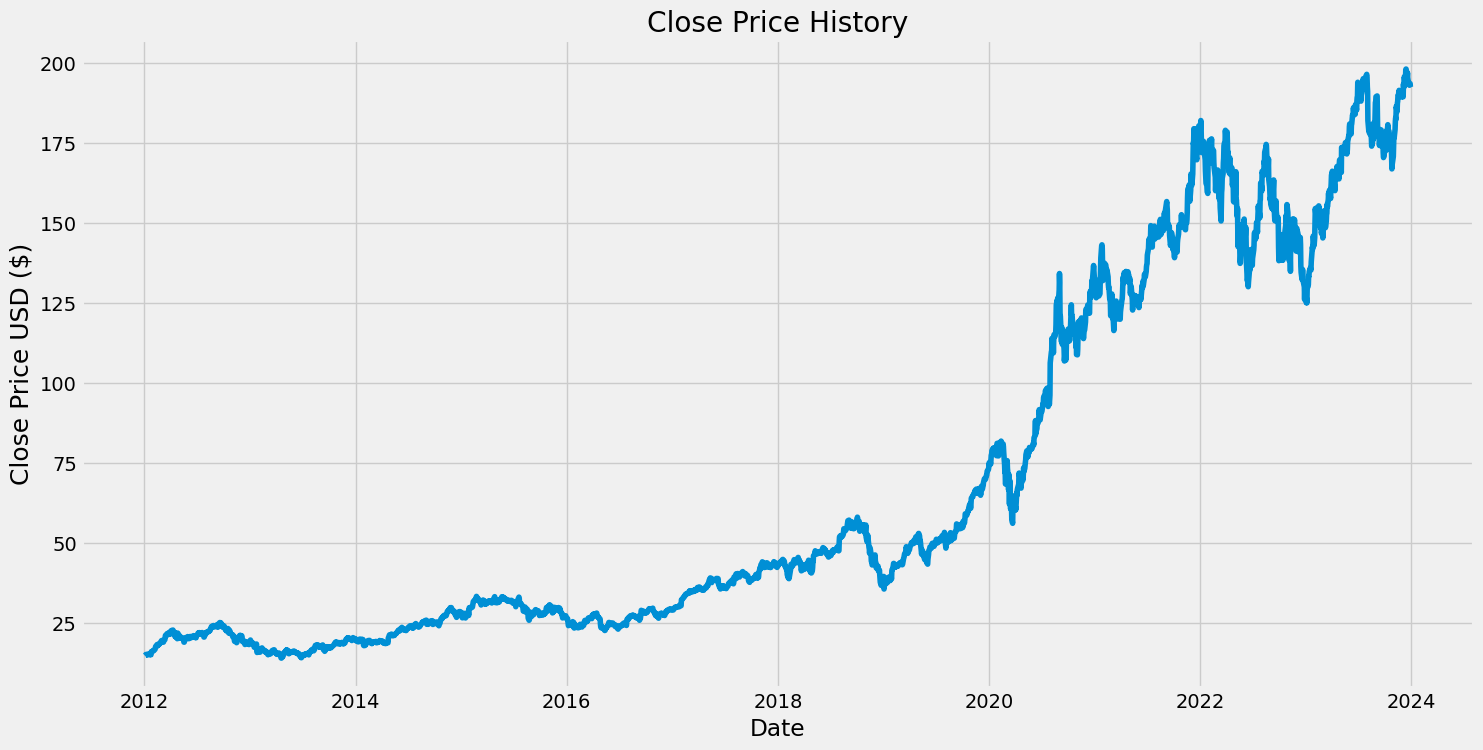

In [7]:
#visualize the closing price history
plt.figure(figsize=(16,8))
plt.title('Close Price History')
plt.plot(df['Close'])
plt.xlabel('Date')
plt.ylabel('Close Price USD ($)',fontsize=18)

In [8]:
#create a new dataframe with only the close col
data=df.filter(['Close'])
#convert into numpy array
dataset=data.values
#get the number of rows to train the model on
training_data_len=math.ceil(len(dataset)*.8) #using 80% of the data to train the model
print(training_data_len)

2415


In [9]:
#scale the data
scaler=MinMaxScaler(feature_range=(0,1))
scaled_data=scaler.fit_transform(dataset)
scaled_data

array([[0.00401431],
       [0.00444289],
       [0.00533302],
       ...,
       [0.97306723],
       [0.97540217],
       [0.96970066]], shape=(3018, 1))

In [10]:
#create the training data set
#create the scaled training data set
train_data=scaled_data[0:training_data_len,:]
#split the data into x_train and y_train datasets
x_train=[]
y_train=[]
for i in range(60,len(train_data)):
    x_train.append(train_data[i-60:i,0])
    y_train.append(train_data[i,0])
    if i<=61:
        print(x_train)
        print(y_train)
        print() 


[array([0.00401431, 0.00444289, 0.00533302, 0.00618049, 0.00605056,
       0.00634339, 0.00620958, 0.00598462, 0.00567821, 0.00662652,
       0.00748175, 0.007218  , 0.00577323, 0.00715207, 0.00579457,
       0.01088518, 0.01049151, 0.01100542, 0.01211663, 0.01278955,
       0.01273332, 0.01252582, 0.01341013, 0.01424207, 0.01518457,
       0.01670691, 0.01990478, 0.01995326, 0.02173353, 0.02306387,
       0.02077746, 0.02165789, 0.02164044, 0.02410915, 0.02375813,
       0.02440779, 0.02557523, 0.0262249 , 0.02809631, 0.02945961,
       0.02985329, 0.02999098, 0.02765997, 0.02709757, 0.02718096,
       0.02937236, 0.02998905, 0.03131358, 0.03443581, 0.03860139,
       0.0378218 , 0.03782373, 0.04083544, 0.04177794, 0.04110694,
       0.04049413, 0.03985611, 0.04197573, 0.0434302 , 0.04403914])]
[np.float64(0.042534249860459186)]

[array([0.00401431, 0.00444289, 0.00533302, 0.00618049, 0.00605056,
       0.00634339, 0.00620958, 0.00598462, 0.00567821, 0.00662652,
       0.00748175, 0.0

In [11]:
#convert the x_train and y_train to numpy arrays
x_train,y_train=np.array(x_train),np.array(y_train) 

In [12]:
x_train=np.reshape(x_train,(x_train.shape[0],x_train.shape[1],1))
x_train.shape

(2355, 60, 1)

In [13]:
#build the lstm model
model=Sequential()
model.add(LSTM(50,return_sequences=True,input_shape=(x_train.shape[1],1)))
model.add(LSTM(50,return_sequences=False))
model.add(Dense(25))
model.add(Dense(1))

C:\Users\Spandan\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [14]:
#complile the model
model.compile(optimizer='adam',loss='mean_squared_error')

In [15]:
#train the model
model.fit(x_train,y_train,batch_size=1,epochs=1)

2355/2355 ━━━━━━━━━━━━━━━━━━━━ 66s 25ms/step - loss: 7.2575e-04


In [16]:
#create the testing dataset
#create a new array containing scaled values from index 1333 to 2002
test_data=scaled_data[training_data_len-60:,:]
#create the datasets x_test and y_test
x_test=[]
y_test=dataset[training_data_len:,:]
for i in range(60,len(test_data)):
    x_test.append(test_data[i-60:i,0])
    

In [17]:
#convert the data to a numpy array
x_test=np.array(x_test)


In [18]:
#reshape the data
x_Test=np.reshape(x_test,(x_test.shape[0],x_test.shape[1],1))

In [23]:
#get the models predicted price values
predictions=model.predict(x_Test)
predictions=scaler.inverse_transform(predictions)

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


In [24]:
#get rmse (root mean squared error)
rmse=np.sqrt(np.mean((predictions-y_test)**2))
rmse

np.float64(6.226947068915715)

C:\Users\Spandan\AppData\Local\Temp\ipykernel_71768\660818748.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid['Predictions']=predictions


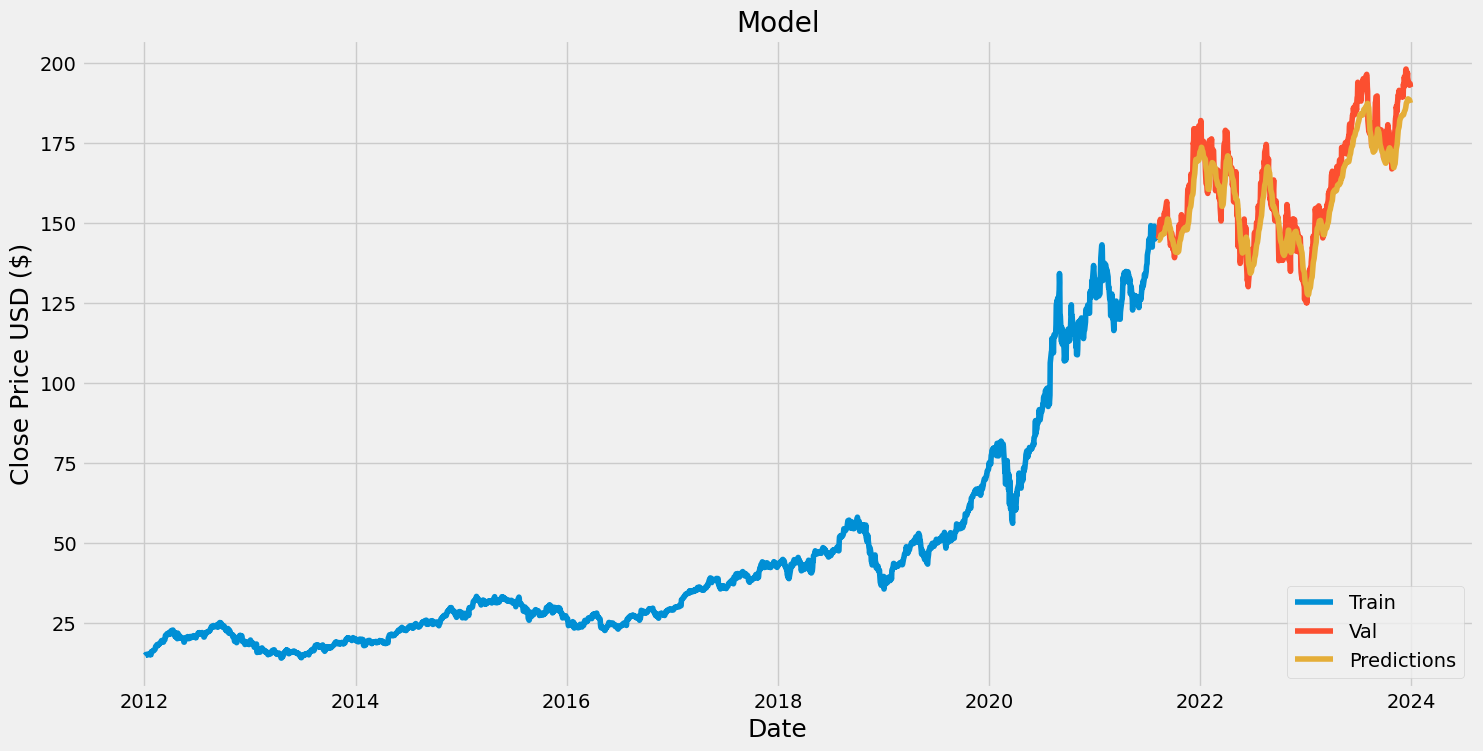

In [26]:
train=data[:training_data_len]
valid=data[training_data_len:]
valid['Predictions']=predictions
#visualize it
plt.figure(figsize=(16,8))
plt.title('Model')
plt.xlabel('Date',fontsize=18)
plt.ylabel('Close Price USD ($)',fontsize=18)
plt.plot(train['Close'])
plt.plot(valid[['Close','Predictions']])
plt.legend(['Train','Val','Predictions'],loc='lower right')
plt.show()

In [27]:
#show the valid and predicted prices
valid

,Close,Predictions
Date,,
2021-08-09 00:00:00-04:00,146.089996,144.820297
2021-08-10 00:00:00-04:00,145.600006,144.793823
2021-08-11 00:00:00-04:00,145.860001,144.705261
2021-08-12 00:00:00-04:00,148.889999,144.616364
2021-08-13 00:00:00-04:00,149.100006,144.802261
...,...,...
2023-12-22 00:00:00-05:00,193.600006,188.703720
2023-12-26 00:00:00-05:00,193.050003,188.465698
2023-12-27 00:00:00-05:00,193.149994,188.124588


In [ ]:
#get the quote
apple_quote=yf.Ticker('AAPL')
#create a new dataframe
new_df=apple_quote.history(period='1y').filter(['Close'])
#get the last 60 day closing price values and convert the dataframe to an array
last_60_days=new_df[-60:].values
#scale the data to be values between 0 and 1
last_60_days_scaled=scaler.transform(last_60_days)
#create an empty list
X_test=[]
#append the past 60 days
X_test.append(last_60_days_scaled)
#convert the X_test data set to a numpy array
X_test=np.array(X_test)
#reshape the data
X_test=np.reshape(X_test,(X_test.shape[0],X_test.shape[1],1))
#get the predicted scaled price
pred_price=model.predict(X_test)
#undo the scaling
pred_price=scaler.inverse_transform(pred_price)
print(pred_price)